# Johnson & Johnson Medical GmbH Assesment




# Would promoting the Deutschlandticket make sense for J&J Medical GmbH employees in Norderstedt?

J&J's site at Robert-Koch-Straße 1, Norderstedt sits at the edge of Hamburg's transit network (U1 + AKN A1). Since real employee addresses can't be used, I build a synthetic but geographically plausible population, estimate each employee's door-to-door commute, and score their Deutschlandticket adoption potential.

**Questions:** (1) what share of commutes fall under 30/45/60 min? (2) how much adoption potential overall? (3) which areas have strong vs. weak connectivity? (4) what drives adoption?


## Approach & key assumptions

Synthetic population (real residential-area anchors) → nearest real HVV/AKN station → estimated door-to-door time → commute grouping → adoption scoring → geographic rollup → recommendations.

- Commute times are **estimated**, not live-routed (full reasoning in `docs/data_sources.md`).
- Population anchored on 9 real areas, not a uniform bounding box.
- Full assumption list: `docs/assumptions.md`.


## Data sources

**Real:** HVV's official GTFS feed (Hamburg open-data portal) and used to identify ral U1/AKN A1 stations.

**Synthetic:** the employee population  — documented in `docs/assumptions.md`.

Full sourcing and limitations: `docs/data_sources.md`, `docs/limitations.md`.


## Environment and imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from config import (
    STATIONS, RESIDENTIAL_AREAS, WORKPLACE_LAT, WORKPLACE_LON, WORKPLACE_NAME,
    COMMUTE_BINS, COMMUTE_LABELS, RANDOM_SEED, N_EMPLOYEES,
)
from data_generation import generate_synthetic_employees
from geospatial import attach_nearest_station
from transport import compute_door_to_door
from scoring import compute_adoption_score
from data_cleaning import run_full_quality_report
import visualization as viz

pd.set_option('display.max_columns', None)
stations_df = pd.DataFrame(STATIONS)
print(f"Workplace: {WORKPLACE_NAME} at ({WORKPLACE_LAT}, {WORKPLACE_LON})")
print(f"Reference stations loaded: {len(stations_df)}")
print(f"Random seed: {RANDOM_SEED}, target population: {N_EMPLOYEES}")


Workplace: Johnson & Johnson Medical GmbH at (53.6947, 9.9959)
Reference stations loaded: 16
Random seed: 42, target population: 500


## Synthetic employee population

Sampling anchored on nine real residential areas (population-weighted), with jitter so employees spread out rather than stack on one point.


In [2]:
employees = generate_synthetic_employees()
employees.head()

,employee_id,home_area,home_lat,home_lon,age_group,household_type,work_days_per_week,driving_license,car_access,current_transport_mode
0,EMP0001,Kaltenkirchen,53.838601,9.931787,35-44,single,5,True,False,public_transport
1,EMP0002,Fuhlsbüttel,53.598916,9.972169,55-64,single,4,True,True,bike
2,EMP0003,Hamburg-Innenstadt,53.570142,9.973732,45-54,single,5,True,True,car
3,EMP0004,Quickborn,53.746431,9.910311,45-54,couple_no_children,5,True,True,car
4,EMP0005,Norderstedt,53.721180,9.991391,25-34,couple_no_children,3,True,True,bike


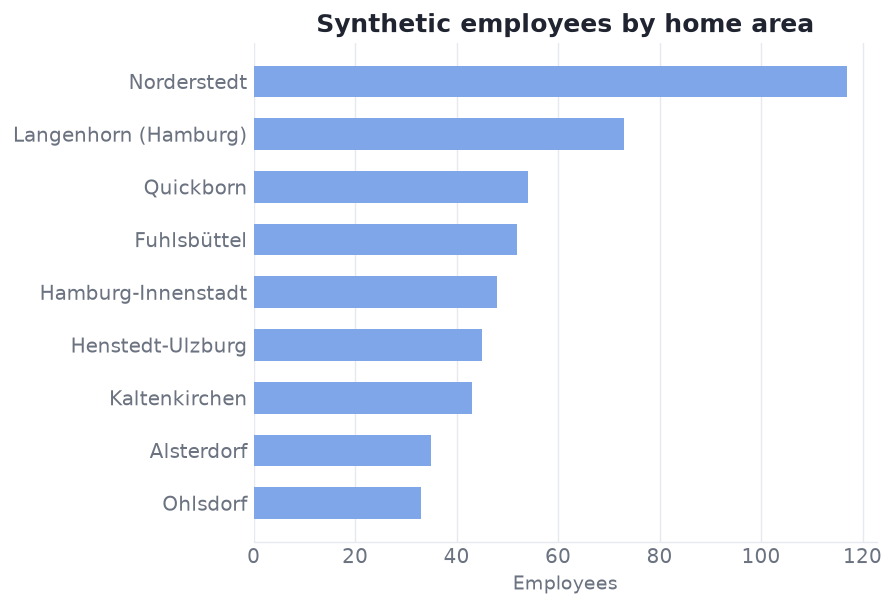

In [3]:
fig = viz.plot_employees_by_area(employees, '../outputs/figures/employees_by_area.png')
plt.show()

## Synthetic data validation

In [4]:
quality_report_raw = run_full_quality_report(employees, 'raw synthetic population')

--- Data quality report: raw synthetic population ---

[missing_duplicates]
  missing_values: {'employee_id': 0, 'home_area': 0, 'home_lat': 0, 'home_lon': 0, 'age_group': 0, 'household_type': 0, 'work_days_per_week': 0, 'driving_license': 0, 'car_access': 0, 'current_transport_mode': 0}
  duplicate_ids: 0
  duplicate_rows: 0

[coordinates]
  n_invalid_coordinates: 0
  invalid_employee_ids: []

[categorical]
  transport_mode_values: [np.str_('bike'), np.str_('car'), np.str_('mixed'), np.str_('public_transport')]


Clean: no missing values, no duplicate IDs, all coordinates inside the expected bounding box.

## Workplace and public transport reference data

Workplace sits near the Norderstedt Mitte U1/AKN interchange. Reference stations below are real HVV/AKN stops (see `docs/limitations.md`).


In [5]:
stations_df

,name,lat,lon,line
0,Norderstedt Mitte,53.6906,9.9885,U1
1,Garstedt,53.6742,9.9932,U1
2,Ochsenzoll,53.6580,10.0068,U1
3,Kiwittsmoor,53.6465,10.0182,U1
4,Langenhorn Nord,53.6395,10.0090,U1
5,Fuhlsbüttel Nord,53.6274,10.0012,U1
6,Alsterdorf,53.6018,9.9987,U1
7,Ohlsdorf,53.6205,10.0202,U1
8,Norderstedt-Mitte AKN,53.6906,9.9885,AKN-A1
9,Friedrichsgabe,53.6975,9.9700,AKN-A1


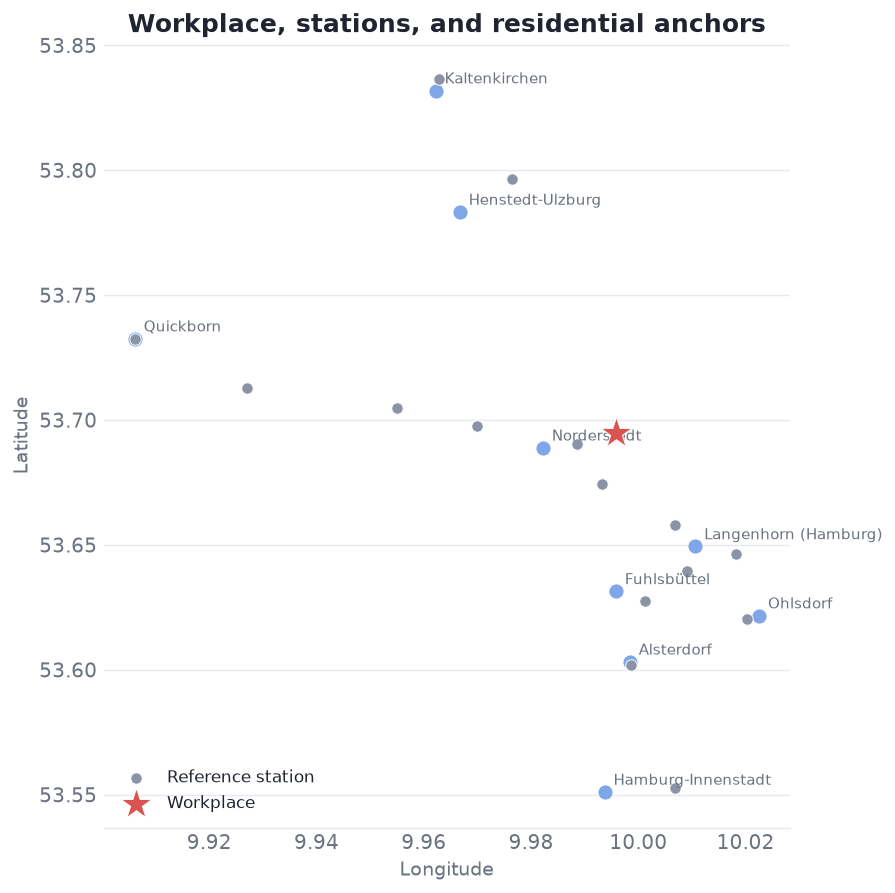

In [6]:
fig = viz.plot_geography_overview(stations_df, RESIDENTIAL_AREAS, '../outputs/figures/geography_overview.png')
plt.show()

## Nearest station

Straight-line (haversine) distance to the nearest reference station — a simplification of real street-network catchment, documented in `docs/methodology.md`.


In [7]:
employees = attach_nearest_station(employees, stations_df)
employees[['employee_id','home_area','nearest_station','station_line','distance_to_station_km']].head()

,employee_id,home_area,nearest_station,station_line,distance_to_station_km
0,EMP0001,Kaltenkirchen,Kaltenkirchen,AKN-A1,2.045819
1,EMP0002,Fuhlsbüttel,Alsterdorf,U1,1.779788
2,EMP0003,Hamburg-Innenstadt,Hamburg Hauptbahnhof,U1,2.918446
3,EMP0004,Quickborn,Quickborn,AKN-A1,1.562688
4,EMP0005,Norderstedt,Friedrichsgabe,AKN-A1,2.985805


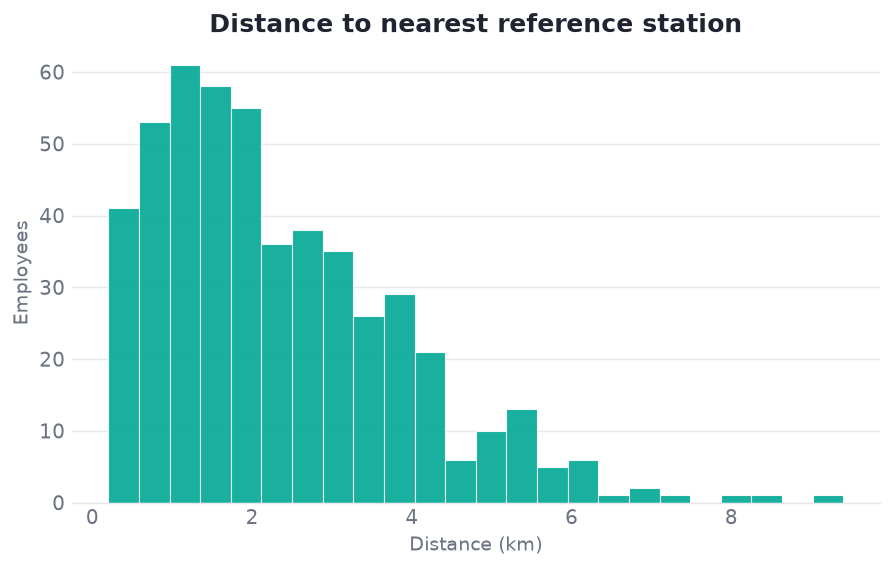

In [8]:
fig = viz.plot_distance_to_station(employees, '../outputs/figures/distance_to_station.png')
plt.show()

## Door-to-door commute time

**Estimated, not observed or routed.**

`door-to-door = walk to station + avg. wait + transit ride (network distance / line speed) + transfer penalty + fixed final walk`

Every component is a documented, configurable constant in `src/config.py` (reasoning in `docs/assumptions.md`).


In [9]:
employees = compute_door_to_door(employees)
employees[['employee_id','walking_time_min','waiting_time_min','transit_time_min',
           'transfer_time_min','final_walk_time_min','door_to_door_time_min']].head()

,employee_id,walking_time_min,waiting_time_min,transit_time_min,transfer_time_min,final_walk_time_min,door_to_door_time_min
0,EMP0001,27.277589,6.0,28.680760,5.0,12.0,78.958348
1,EMP0002,23.730512,6.0,26.239635,0.0,12.0,67.970147
2,EMP0003,38.912615,6.0,33.947307,0.0,12.0,90.859923
3,EMP0004,20.835834,6.0,13.953226,5.0,12.0,57.789060
4,EMP0005,39.810730,6.0,5.129484,5.0,12.0,67.940214


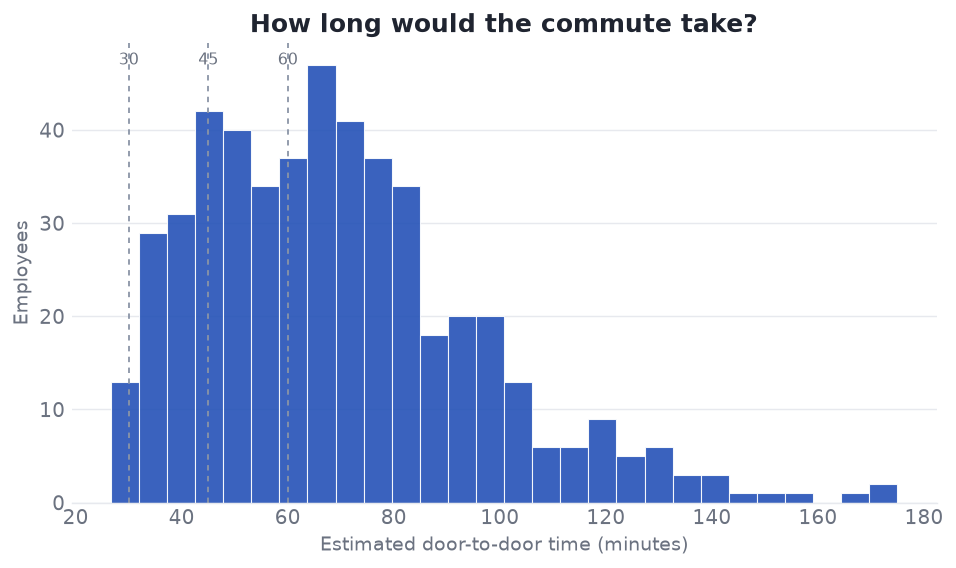

In [10]:
fig = viz.plot_commute_time_distribution(employees, '../outputs/figures/commute_time_distribution.png')
plt.show()

## Commute-time grouping

Mutually exclusive group counts and cumulative percentages are shown separately.


In [11]:
employees['commute_group'] = pd.cut(
    employees['door_to_door_time_min'], bins=COMMUTE_BINS, labels=COMMUTE_LABELS
)

group_counts = employees['commute_group'].value_counts().reindex(COMMUTE_LABELS)
group_pct = (100 * group_counts / len(employees)).round(1)

print("Mutually exclusive groups:")
for label, cnt, pct in zip(COMMUTE_LABELS, group_counts, group_pct):
    print(f"  {label}: {cnt} employees ({pct}%)")

cum_30 = (employees['door_to_door_time_min'] <= 30).mean() * 100
cum_45 = (employees['door_to_door_time_min'] <= 45).mean() * 100
cum_60 = (employees['door_to_door_time_min'] <= 60).mean() * 100
cum_over60 = 100 - cum_60

print("\nCumulative percentages:")
print(f"  Within 30 min: {cum_30:.1f}%")
print(f"  Within 45 min: {cum_45:.1f}%")
print(f"  Within 60 min: {cum_60:.1f}%")
print(f"  Over 60 min:   {cum_over60:.1f}%")

Mutually exclusive groups:
  <=30 min: 8 employees (1.6%)
  31-45 min: 80 employees (16.0%)
  46-60 min: 113 employees (22.6%)
  >60 min: 299 employees (59.8%)

Cumulative percentages:
  Within 30 min: 1.6%
  Within 45 min: 17.6%
  Within 60 min: 40.2%
  Over 60 min:   59.8%


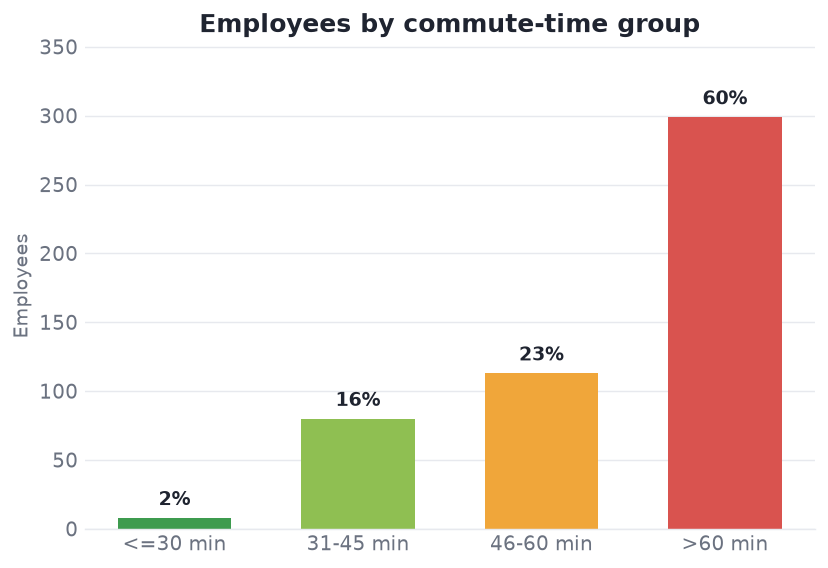

In [12]:
fig = viz.plot_commute_groups(employees, '../outputs/figures/commute_groups.png')
plt.show()

**Reading this:** most of the population falls outside 60 minutes — largely because the 16-station reference set is sparser than HVV's real network, and Norderstedt sits at the network's edge. 

## Deutschlandticket adoption potential

An interpretable **Estimated Adoption Potential** score (0–100), there's no observed adoption outcome to learn from. Four weighted components: commute time, connectivity, car-access penalty, current mode (`src/scoring.py`, `docs/assumptions.md`).


In [13]:
employees = compute_adoption_score(employees)
employees[['employee_id','commute_time_score','connectivity_score','car_access_penalty',
           'current_mode_score','adoption_potential_score','adoption_potential_group']].head()

,employee_id,commute_time_score,connectivity_score,car_access_penalty,current_mode_score,adoption_potential_score,adoption_potential_group
0,EMP0001,17.424055,14.062753,100.0,100.0,45.3,Medium potential
1,EMP0002,34.763762,43.559631,30.0,50.0,38.7,Low potential
2,EMP0003,0.000000,2.911344,30.0,20.0,9.9,Low potential
3,EMP0004,50.829820,31.309790,30.0,20.0,36.2,Low potential
4,EMP0005,34.810997,0.000000,30.0,50.0,25.7,Low potential


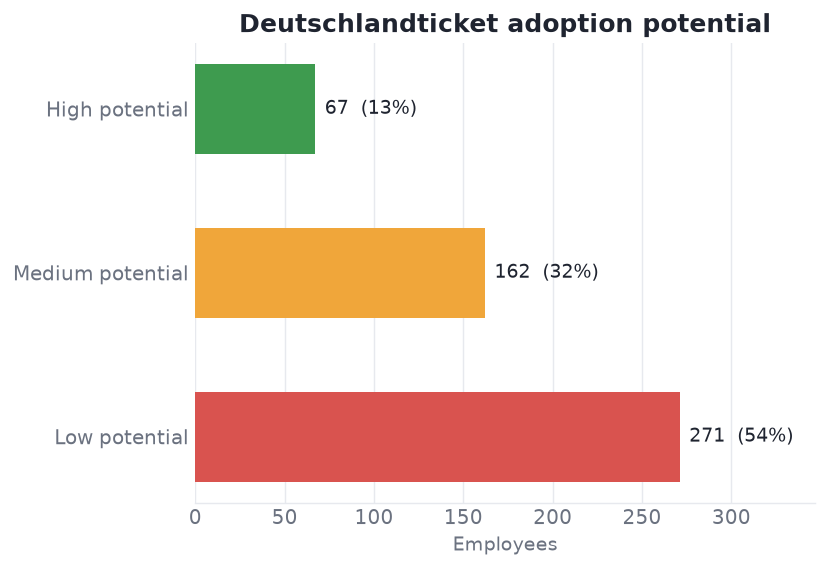

High potential: 67 employees (13.4%)
Medium potential: 162 employees (32.4%)
Low potential: 271 employees (54.2%)


In [14]:
fig = viz.plot_adoption_distribution(employees, '../outputs/figures/adoption_distribution.png')
plt.show()

adoption_counts = employees['adoption_potential_group'].value_counts()
adoption_pct = (100 * adoption_counts / len(employees)).round(1)
for grp in ['High potential','Medium potential','Low potential']:
    print(f"{grp}: {adoption_counts.get(grp,0)} employees ({adoption_pct.get(grp,0)}%)")

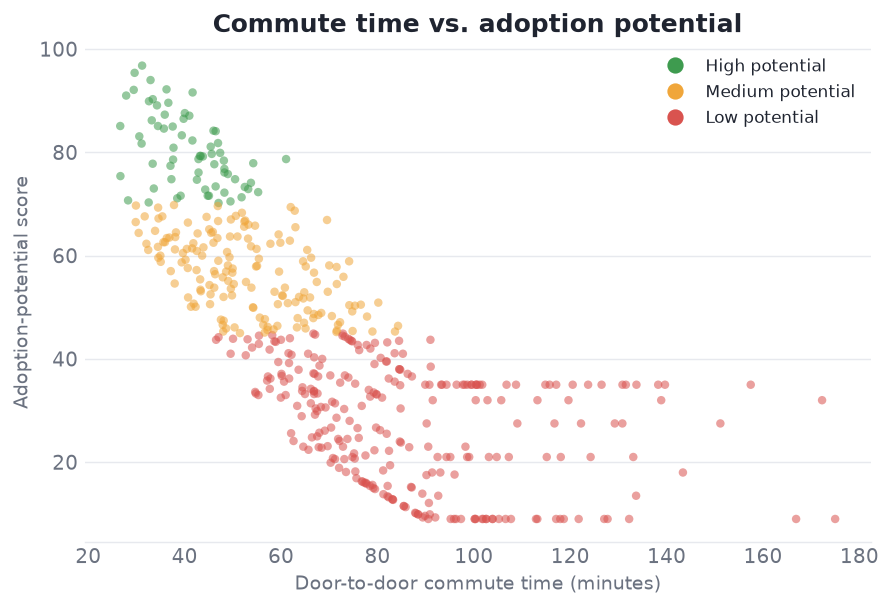

In [15]:
fig = viz.plot_commute_vs_adoption(employees, '../outputs/figures/commute_vs_adoption.png')
plt.show()

**Reading this:** adoption potential tracks commute time but isn't determined by it — car access and current mode also pull the score, so a middling commute with no car access can still score high-potential.

## Data quality checks (post-enrichment)

In [16]:
quality_report_full = run_full_quality_report(employees, 'full enriched dataset')

--- Data quality report: full enriched dataset ---

[missing_duplicates]
  missing_values: {'employee_id': 0, 'home_area': 0, 'home_lat': 0, 'home_lon': 0, 'age_group': 0, 'household_type': 0, 'work_days_per_week': 0, 'driving_license': 0, 'car_access': 0, 'current_transport_mode': 0, 'nearest_station': 0, 'station_line': 0, 'distance_to_station_km': 0, 'walking_time_min': 0, 'waiting_time_min': 0, 'transit_time_min': 0, 'n_transfers': 0, 'transfer_time_min': 0, 'final_walk_time_min': 0, 'door_to_door_time_min': 0, 'commute_group': 0, 'commute_time_score': 0, 'connectivity_score': 0, 'car_access_penalty': 0, 'current_mode_score': 0, 'adoption_potential_score': 0, 'adoption_potential_group': 0}
  duplicate_ids: 0
  duplicate_rows: 0

[coordinates]
  n_invalid_coordinates: 0
  invalid_employee_ids: []

[commute_time]
  n_negative: 0
  n_implausibly_low_(<5min): 0
  n_implausibly_high_(>150min): 5
  min: 26.62983679824212
  max: 174.96637441397795
  mean: 69.43367701050295
  median: 66.75

No negative or invalid values. A handful of employees exceed 150 minutes — legitimately far-flung homes (e.g. Kaltenkirchen via AKN with a transfer penalty), not errors, so left in rather than dropped.

## Validation and sanity checks

- **Distance from Norderstedt tracks commute time?** Yes.
- **U1-served areas beat AKN-only areas?** Generally yes (faster line speed, more anchors served).
- **Transport-mode mix plausible?** Yes, car-access employees skew toward driving. This validates the generation logic.


In [17]:
area_summary = employees.groupby('home_area').agg(
    n_employees=('employee_id','count'),
    mean_door_to_door_min=('door_to_door_time_min','mean'),
    median_door_to_door_min=('door_to_door_time_min','median'),
    pct_within_45min=('door_to_door_time_min', lambda x: 100*(x<=45).mean()),
    mean_adoption_score=('adoption_potential_score','mean'),
    pct_high_potential=('adoption_potential_group', lambda x: 100*(x=='High potential').mean()),
).round(1).reset_index().sort_values('mean_door_to_door_min')

area_summary

,home_area,n_employees,mean_door_to_door_min,median_door_to_door_min,pct_within_45min,mean_adoption_score,pct_high_potential
6,Norderstedt,117,53.1,48.2,39.3,52.7,23.1
5,Langenhorn (Hamburg),73,57.3,48.6,38.4,53.3,19.2
7,Ohlsdorf,33,62.5,60.1,15.2,52.0,21.2
1,Fuhlsbüttel,52,65.2,59.5,11.5,52.2,25.0
0,Alsterdorf,35,72.4,72.3,2.9,37.6,2.9
8,Quickborn,54,73.6,72.8,3.7,36.9,5.6
4,Kaltenkirchen,43,84.4,78.5,0.0,34.9,2.3
3,Henstedt-Ulzburg,45,84.5,83.1,0.0,27.0,0.0
2,Hamburg-Innenstadt,48,102.6,97.3,0.0,31.4,2.1


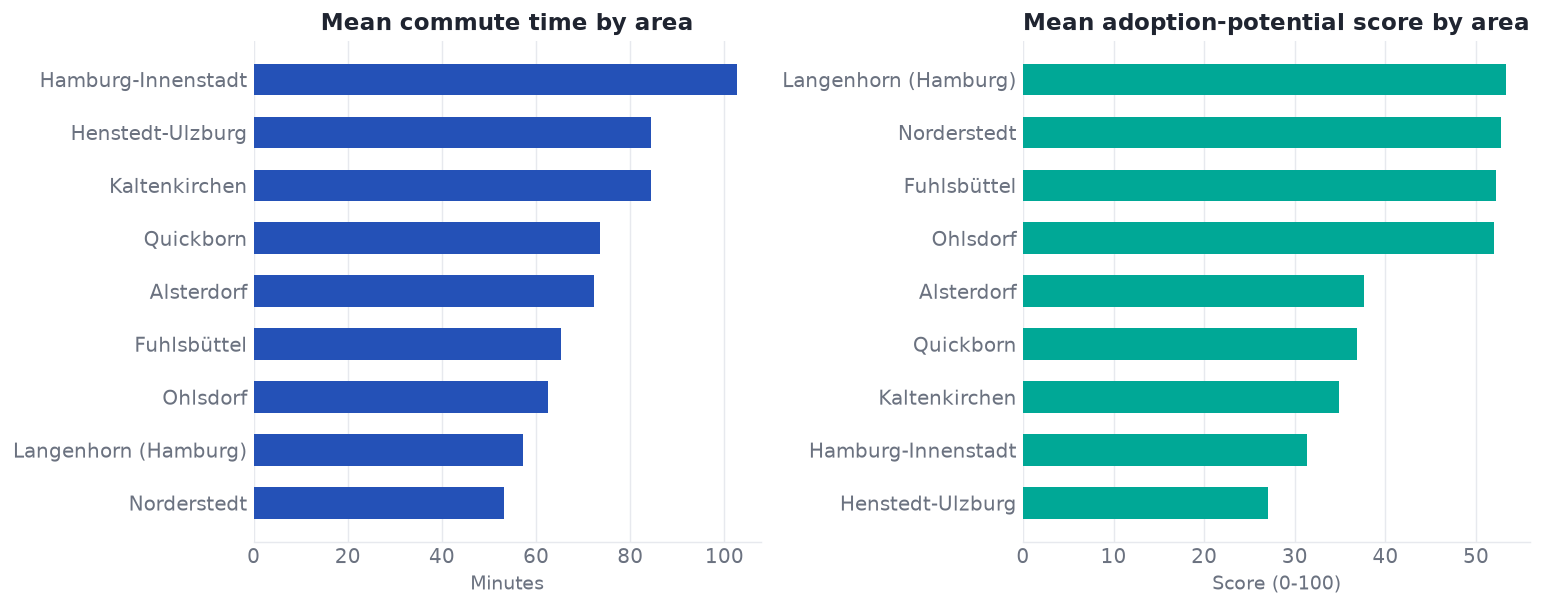

In [18]:
fig = viz.plot_area_summary(area_summary, '../outputs/figures/area_summary.png')
plt.show()

## Sensitivity analysis

Testing the two most uncertain inputs, average wait time and walking speed across three scenarios, rather than an exhaustive grid.


In [19]:
from transport import walking_time_minutes, estimate_transit_leg
from geospatial import haversine_km

def recompute_door_to_door(df, wait_min, walk_speed_kmh):
    walk = walking_time_minutes(df['distance_to_station_km'], speed_kmh=walk_speed_kmh)
    transit_km = haversine_km(df['home_lat'].values, df['home_lon'].values, WORKPLACE_LAT, WORKPLACE_LON)
    transit = [estimate_transit_leg(d, line) for d, line in zip(transit_km, df['station_line'])]
    total = walk + wait_min + pd.Series(transit, index=df.index) + df['transfer_time_min'] + df['final_walk_time_min']
    return total

scenarios = {
    'Base case (6 min wait, 4.5 km/h walk)': (6.0, 4.5),
    'Optimistic (4 min wait, 5.0 km/h walk)': (4.0, 5.0),
    'Pessimistic (10 min wait, 4.0 km/h walk)': (10.0, 4.0),
}

print(f"{'Scenario':40s} {'<=30min':>8s} {'<=45min':>8s} {'<=60min':>8s} {'>60min':>8s}")
for name, (wait, speed) in scenarios.items():
    times = recompute_door_to_door(employees, wait, speed)
    p30 = (times <= 30).mean() * 100
    p45 = (times <= 45).mean() * 100
    p60 = (times <= 60).mean() * 100
    p60p = 100 - p60
    print(f"{name:40s} {p30:7.1f}% {p45:7.1f}% {p60:7.1f}% {p60p:7.1f}%")

Scenario                                  <=30min  <=45min  <=60min   >60min
Base case (6 min wait, 4.5 km/h walk)        1.6%    17.6%    40.2%    59.8%
Optimistic (4 min wait, 5.0 km/h walk)       3.4%    25.4%    46.8%    53.2%
Pessimistic (10 min wait, 4.0 km/h walk)     0.0%    11.2%    31.8%    68.2%


**Conclusion:** percentages shift a few points between scenarios, but the pattern holds. Headline finding: **robust**. Exact percentages: **somewhat sensitive** .

## Geographic analysis

In [20]:
strong_areas = area_summary.sort_values('pct_within_45min', ascending=False).head(3)
weak_areas = area_summary.sort_values('pct_within_45min', ascending=True).head(3)

print("Strongest connectivity (highest % within 45 min):")
print(strong_areas[['home_area','pct_within_45min','mean_door_to_door_min']].to_string(index=False))

print("\nWeakest connectivity (lowest % within 45 min):")
print(weak_areas[['home_area','pct_within_45min','mean_door_to_door_min']].to_string(index=False))

Strongest connectivity (highest % within 45 min):
           home_area  pct_within_45min  mean_door_to_door_min
         Norderstedt              39.3                   53.1
Langenhorn (Hamburg)              38.4                   57.3
            Ohlsdorf              15.2                   62.5

Weakest connectivity (lowest % within 45 min):
         home_area  pct_within_45min  mean_door_to_door_min
     Kaltenkirchen               0.0                   84.4
  Henstedt-Ulzburg               0.0                   84.5
Hamburg-Innenstadt               0.0                  102.6


## Interactive map

Workplace, reference stations, synthetic employee homes coloured by commute-time group, and a toggleable layer for high-adoption-potential employees. 


In [21]:
m = viz.build_interactive_map(employees, stations_df, '../outputs/maps/commute_map.html')
m

## Key findings

- Estimated door-to-door commute time within 30 minutes: **see cumulative percentages above** — a small minority, concentrated in Norderstedt itself.
- The majority of the synthetic population falls above the 45–60 minute range under current assumptions, driven mainly by distance from the Norderstedt corridor and, for AKN-served areas, the added transfer penalty.
- Adoption potential correlates with commute time but is also meaningfully shaped by car access and current transport mode — employees without easy car access score as high-potential even with a middling commute.
- Norderstedt and the areas directly along the U1 corridor (Langenhorn, Ohlsdorf) show the strongest connectivity; Hamburg-Innenstadt and the AKN-only towns (Kaltenkirchen, Henstedt-Ulzburg) show the weakest, in this scenario's station-reference setup.


## Business recommendations

1. **Target Deutschlandticket communication toward Norderstedt and U1-corridor residents first** — this is where the commute-time case for switching is strongest and adoption-potential scores are highest.
2. **For AKN-served areas (Kaltenkirchen, Henstedt-Ulzburg, Quickborn), the case is weaker on commute time alone** — any promotion here would need to lean on cost savings or environmental messaging rather than convenience.
3. **Employees without car access are a natural early-adopter segment regardless of area** — they already score higher on adoption potential because public transport is closer to their only realistic option.
4. **What this analysis cannot tell you:** actual willingness to pay, price sensitivity to the Deutschlandticket's cost, or real employee behaviour — none of that exists in this synthetic scenario. It also can't tell you real HVV schedule reliability or frequency, since commute times here are estimated, not routed against a live timetable.


## Limitations

Full detail in `docs/limitations.md`. In summary:
- Commute times are estimated from a documented formula, not routed against a live HVV timetable.
- The station reference set (16 stations) is a simplification of the real, much denser HVV/AKN network, which likely overstates walking distances and commute times for areas not directly on my chosen corridor.
- The synthetic employee population does not represent real J&J staff, and there is no observed Deutschlandticket adoption data anywhere in this analysis — the adoption score is a transparent heuristic, not a validated prediction.
- Sensitivity analysis covered two of the more uncertain inputs (wait time, walking speed); scoring weights themselves were not stress-tested here.


## Conclusion

Within this synthetic scenario and the assumptions documented above, public transport looks genuinely attractive for employees living in and immediately around Norderstedt, and considerably less attractive further out along the AKN corridor. That split rather than a single population-wide percentage is the more defensible takeaway, and it points toward a targeted rather than blanket Deutschlandticket communication strategy.
